In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Veri yükle
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')


In [3]:
# Genel bakış
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df['Churn'].value_counts(normalize=True))

(7043, 21)
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod

In [4]:
# TotalCharges string -> float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


/var/folders/kz/lshxkfvx5f3d4x28v2tdd8gc0000gn/T/ipykernel_4389/763696156.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [5]:
# Churn -> binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

/var/folders/kz/lshxkfvx5f3d4x28v2tdd8gc0000gn/T/ipykernel_4389/4021461214.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


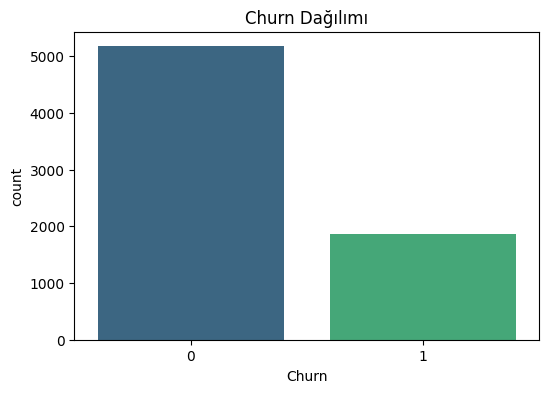

In [6]:
# Churn dağılımı
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Churn Dağılımı')
plt.savefig('../data/processed/churn_distribution.png')
plt.show()

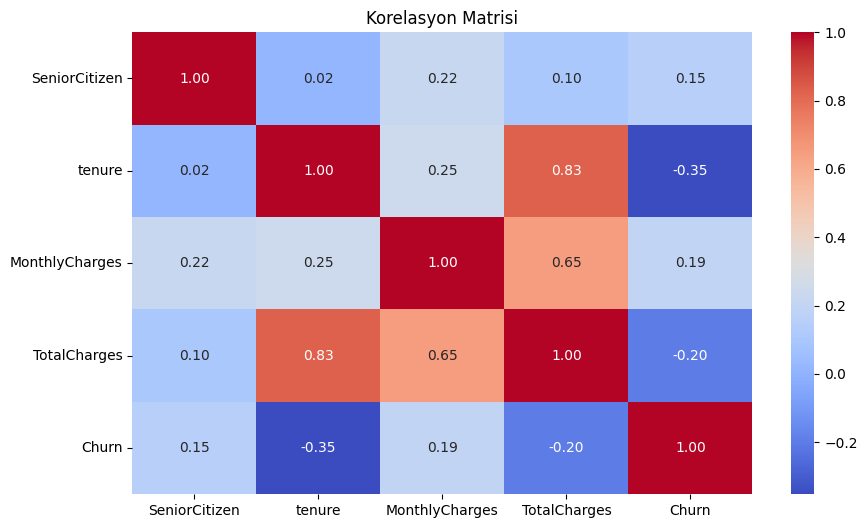

In [7]:
# Sayısal değişkenler korelasyon
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelasyon Matrisi')
plt.savefig('../data/processed/correlation_matrix.png')
plt.show()

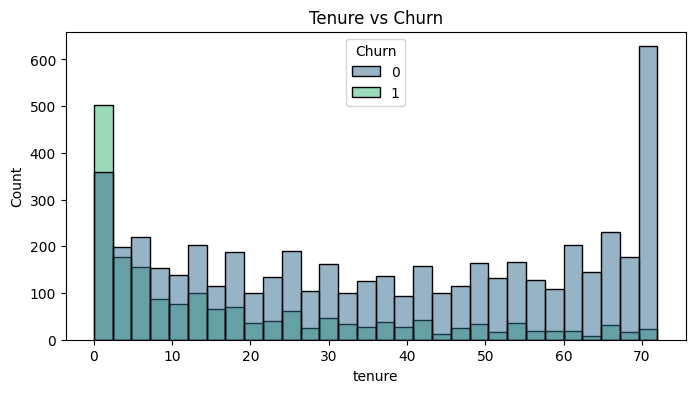

In [8]:
# Tenure vs Churn
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette='viridis')
plt.title('Tenure vs Churn')
plt.savefig('../data/processed/tenure_churn.png')
plt.show()

/var/folders/kz/lshxkfvx5f3d4x28v2tdd8gc0000gn/T/ipykernel_4389/2521825771.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='viridis')


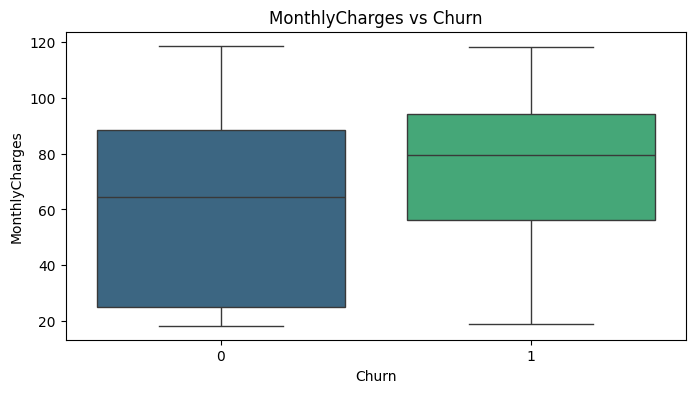

In [9]:
# MonthlyCharges vs Churn
plt.figure(figsize=(8,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='viridis')
plt.title('MonthlyCharges vs Churn')
plt.savefig('../data/processed/monthly_charges_churn.png')
plt.show()


In [10]:
# İşlenmiş veriyi kaydet
df.to_csv('../data/processed/telco_cleaned.csv', index=False)
print("Temizlenmiş veri kaydedildi.")

Temizlenmiş veri kaydedildi.
